# Gradient Boosting Machine

--- Gradient Boosting Model Results ---
Area Under the Curve (AUC): 0.9292
Accuracy: 0.8571

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       117
           1       0.85      0.85      0.85       107

    accuracy                           0.86       224
   macro avg       0.86      0.86      0.86       224
weighted avg       0.86      0.86      0.86       224


Top 10 Feature Importances:
 ST_Slope_Up          0.484202
MaxHR                0.101784
Oldpeak              0.097017
ExerciseAngina_Y     0.074035
Sex_M                0.068790
Age                  0.051784
RestingBP            0.029303
Cholesterol          0.022523
ST_Slope_Flat        0.021423
ChestPainType_ATA    0.015787
dtype: float64


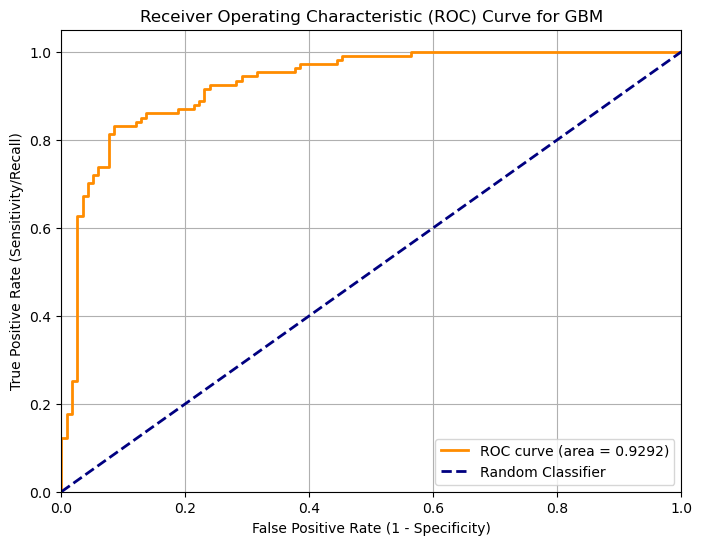

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- 1. Load Data ---
# Load the dataset
df = pd.read_csv('heart-cleaned.csv')

# --- 2. Data Preprocessing (One-Hot Encoding) ---
# Identify categorical columns for encoding
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# --- 3. Train-Test Split ---
# Split the data into 70% training and 30% testing, using stratify to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- 4. Gradient Boosting Model (GBM) Training ---
# Initialize and train the classifier
gbm_model = GradientBoostingClassifier(random_state=42)
gbm_model.fit(X_train, y_train)

# --- 5. Model Evaluation and ROC/AUC Calculation ---

# Get predicted probabilities for the positive class (HeartDisease = 1)
y_prob = gbm_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics (False Positive Rate, True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC)
roc_auc = roc_auc_score(y_test, y_prob)

# Get hard predictions for standard metrics
y_pred = gbm_model.predict(X_test)

# --- 6. Print Results ---
print("--- Gradient Boosting Model Results ---")
print(f"Area Under the Curve (AUC): {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 7. Print top feature importances ---
feature_importance = pd.Series(gbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
print("\nTop 10 Feature Importances:\n", feature_importance)

# --- 8. Plot ROC Curve ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve for GBM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()